In [11]:
import pandas as pd
import numpy as np
import random
random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
train_data = pd.read_csv('../data/HIV/Ab_unseen/train_seed0.csv')

In [12]:
train_data

In [4]:
import ast
train_df = train_data.copy()
train_df['HCDR3_w2v'] = train_df['HCDR3_w2v'].apply(ast.literal_eval)
train_df['LCDR3_w2v'] = train_df['LCDR3_w2v'].apply(ast.literal_eval)
train_df['HCDR2_w2v'] = train_df['HCDR2_w2v'].apply(ast.literal_eval)
train_df['LCDR2_w2v'] = train_df['LCDR2_w2v'].apply(ast.literal_eval)
train_df['HCDR1_w2v'] = train_df['HCDR1_w2v'].apply(ast.literal_eval)
train_df['LCDR1_w2v'] = train_df['LCDR1_w2v'].apply(ast.literal_eval)
train_df['FRH3_w2v'] = train_df['FRH3_w2v'].apply(ast.literal_eval)
train_df['FRL3_w2v'] = train_df['FRL3_w2v'].apply(ast.literal_eval)
train_df['FRH2_w2v'] = train_df['FRH2_w2v'].apply(ast.literal_eval)
train_df['FRL2_w2v'] = train_df['FRL2_w2v'].apply(ast.literal_eval)
train_df['FRH1_w2v'] = train_df['FRH1_w2v'].apply(ast.literal_eval)
train_df['FRL1_w2v'] = train_df['FRL1_w2v'].apply(ast.literal_eval)

In [5]:
train_HCDR3 = np.vstack(train_df["HCDR3_w2v"].values)
train_LCDR3 = np.vstack(train_df["LCDR3_w2v"].values)
train_HCDR2 = np.vstack(train_df["HCDR2_w2v"].values)
train_LCDR2 = np.vstack(train_df["LCDR2_w2v"].values)
train_HCDR1 = np.vstack(train_df["HCDR1_w2v"].values)
train_LCDR1 = np.vstack(train_df["LCDR1_w2v"].values)
train_FRH3 = np.vstack(train_df["FRH3_w2v"].values)
train_FRL3 = np.vstack(train_df["FRL3_w2v"].values)
train_FRH2 = np.vstack(train_df["FRH2_w2v"].values)
train_FRL2 = np.vstack(train_df["FRL2_w2v"].values)
train_FRH1 = np.vstack(train_df["FRH1_w2v"].values)
train_FRL1 = np.vstack(train_df["FRL1_w2v"].values)

In [6]:
Train_fea = np.concatenate([train_HCDR3, train_LCDR3, train_HCDR2, train_LCDR2, train_HCDR1, train_LCDR1,
                            train_FRH3, train_FRL3, train_FRH2, train_FRL2, train_FRH1, train_FRL1], axis=1)

In [8]:
# Shuffle dataset to eliminate batch effect
features = Train_fea
labels = np.array(list(train_df['label'].values))


In [13]:
from autogluon.tabular import TabularPredictor
import os

# ========= 4️转换为 DataFrame =========
label_col = 'label'

def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

train_df = to_df(features, labels)
# test_df = to_df(X_test)   # ❗测试集不要标签

# ========= 5️设置模型保存路径 =========
outdir = "Model save path!"
os.makedirs(outdir, exist_ok=True)

# ========= 6️训练模型 =========
predictor = TabularPredictor(
    label=label_col,
    path=outdir,
    problem_type='binary',
    eval_metric='roc_auc'
).fit(
    train_data=train_df,
    num_bag_folds=10,
    num_bag_sets=1,
    presets='best_quality',
    verbosity=2
)


In [ ]:
### test ####

In [2]:
test_data = pd.read_csv('../data/HIV/Ab_unseen/test_seed0.csv')

In [4]:
import ast
test_df = test_data.copy()
test_df['HCDR3_w2v'] = test_df['HCDR3_w2v'].apply(ast.literal_eval)
test_df['LCDR3_w2v'] = test_df['LCDR3_w2v'].apply(ast.literal_eval)
test_df['HCDR2_w2v'] = test_df['HCDR2_w2v'].apply(ast.literal_eval)
test_df['LCDR2_w2v'] = test_df['LCDR2_w2v'].apply(ast.literal_eval)
test_df['HCDR1_w2v'] = test_df['HCDR1_w2v'].apply(ast.literal_eval)
test_df['LCDR1_w2v'] = test_df['LCDR1_w2v'].apply(ast.literal_eval)
test_df['FRH3_w2v'] = test_df['FRH3_w2v'].apply(ast.literal_eval)
test_df['FRL3_w2v'] = test_df['FRL3_w2v'].apply(ast.literal_eval)
test_df['FRH2_w2v'] = test_df['FRH2_w2v'].apply(ast.literal_eval)
test_df['FRL2_w2v'] = test_df['FRL2_w2v'].apply(ast.literal_eval)
test_df['FRH1_w2v'] = test_df['FRH1_w2v'].apply(ast.literal_eval)
test_df['FRL1_w2v'] = test_df['FRL1_w2v'].apply(ast.literal_eval)

In [5]:
test_HCDR3 = np.vstack(test_df["HCDR3_w2v"].values)
test_LCDR3 = np.vstack(test_df["LCDR3_w2v"].values)
test_HCDR2 = np.vstack(test_df["HCDR2_w2v"].values)
test_LCDR2 = np.vstack(test_df["LCDR2_w2v"].values)
test_HCDR1 = np.vstack(test_df["HCDR1_w2v"].values)
test_LCDR1 = np.vstack(test_df["LCDR1_w2v"].values)
test_FRH3 = np.vstack(test_df["FRH3_w2v"].values)
test_FRL3 = np.vstack(test_df["FRL3_w2v"].values)
test_FRH2 = np.vstack(test_df["FRH2_w2v"].values)
test_FRL2 = np.vstack(test_df["FRL2_w2v"].values)
test_FRH1 = np.vstack(test_df["FRH1_w2v"].values)
test_FRL1 = np.vstack(test_df["FRL1_w2v"].values)

In [6]:
Test_fea = np.concatenate([test_HCDR3, test_LCDR3, test_HCDR2, test_LCDR2, test_HCDR1, test_LCDR1,
                           test_FRH3, test_FRL3, test_FRH2, test_FRL2, test_FRH1, test_FRL1], axis=1)

In [7]:
labels_test = np.array(list(test_df['label'].values))

In [8]:
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor.load("Model save path！")

In [9]:
def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

In [10]:
test_df = to_df(Test_fea)

In [11]:
y_pred = predictor.predict(test_df)
y_prob = predictor.predict_proba(test_df)[1]

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(labels_test, y_prob)   # ROC AUC
aupr = average_precision_score(labels_test, y_prob)  # AUPR

print("AUC =", auc)
print("AUPR =", aupr)

In [2]:
import ast
from autogluon.tabular import TabularPredictor
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import Counter
from sklearn.metrics import roc_auc_score, roc_curve

In [3]:
def to_df(X, y=None):
    cols = [f'f{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    if y is not None:
        df[label_col] = y
    return df

In [6]:
auc_list = []
all_tts_aucs = []
all_tts_permy_aucs = []
all_tts_fprs = []
all_tts_tprs = []
all_tts_permy_fprs = []
all_tts_permy_tprs = []

In [15]:
for seed in range(5):
    test_data = pd.read_csv(f'../data/HIV/Ab_unseen/test_seed{seed}.csv')

    test_df = test_data.copy()
    test_df['HCDR3_w2v'] = test_df['HCDR3_w2v'].apply(ast.literal_eval)
    test_df['LCDR3_w2v'] = test_df['LCDR3_w2v'].apply(ast.literal_eval)
    test_df['HCDR2_w2v'] = test_df['HCDR2_w2v'].apply(ast.literal_eval)
    test_df['LCDR2_w2v'] = test_df['LCDR2_w2v'].apply(ast.literal_eval)
    test_df['HCDR1_w2v'] = test_df['HCDR1_w2v'].apply(ast.literal_eval)
    test_df['LCDR1_w2v'] = test_df['LCDR1_w2v'].apply(ast.literal_eval)
    test_df['FRH3_w2v'] = test_df['FRH3_w2v'].apply(ast.literal_eval)
    test_df['FRL3_w2v'] = test_df['FRL3_w2v'].apply(ast.literal_eval)
    test_df['FRH2_w2v'] = test_df['FRH2_w2v'].apply(ast.literal_eval)
    test_df['FRL2_w2v'] = test_df['FRL2_w2v'].apply(ast.literal_eval)
    test_df['FRH1_w2v'] = test_df['FRH1_w2v'].apply(ast.literal_eval)
    test_df['FRL1_w2v'] = test_df['FRL1_w2v'].apply(ast.literal_eval)

    test_HCDR3 = np.vstack(test_df["HCDR3_w2v"].values)
    test_LCDR3 = np.vstack(test_df["LCDR3_w2v"].values)
    test_HCDR2 = np.vstack(test_df["HCDR2_w2v"].values)
    test_LCDR2 = np.vstack(test_df["LCDR2_w2v"].values)
    test_HCDR1 = np.vstack(test_df["HCDR1_w2v"].values)
    test_LCDR1 = np.vstack(test_df["LCDR1_w2v"].values)
    test_FRH3 = np.vstack(test_df["FRH3_w2v"].values)
    test_FRL3 = np.vstack(test_df["FRL3_w2v"].values)
    test_FRH2 = np.vstack(test_df["FRH2_w2v"].values)
    test_FRL2 = np.vstack(test_df["FRL2_w2v"].values)
    test_FRH1 = np.vstack(test_df["FRH1_w2v"].values)
    test_FRL1 = np.vstack(test_df["FRL1_w2v"].values)

    Test_fea = np.concatenate([test_HCDR3, test_LCDR3, test_HCDR2, test_LCDR2, test_HCDR1, test_LCDR1,
                           test_FRH3, test_FRL3, test_FRH2, test_FRL2, test_FRH1, test_FRL1], axis=1)

    labels_test = np.array(list(test_df['label'].values))
    labels_test_perm = np.random.binomial(n=1, p=(Counter(labels_test)[1.0]/len(labels_test)), size=[len(labels_test)]) # random ys



    predictor = TabularPredictor.load(f"The path where the corresponding random seed model is saved/")

    test_df = to_df(Test_fea)

    y_pred = predictor.predict(test_df)
    y_prob = predictor.predict_proba(test_df)[1]

    # ===================== 计算真实标签指标 =====================
    auc = roc_auc_score(labels_test, y_prob)
    fpr, tpr, _ = roc_curve(labels_test, y_prob)

    # ===================== 计算随机标签指标 =====================
    auc_perm = roc_auc_score(labels_test_perm, y_prob)
    fpr_perm, tpr_perm, _ = roc_curve(labels_test_perm, y_prob)

    # ===================== 存入列表 =====================
    all_tts_aucs.append(auc)
    all_tts_permy_aucs.append(auc_perm)
    all_tts_fprs.append(fpr)
    all_tts_tprs.append(tpr)
    all_tts_permy_fprs.append(fpr_perm)
    all_tts_permy_tprs.append(tpr_perm)

    # ===================== 打印本次结果 =====================
    print(f"seed {seed} | AUC = {auc:.4f} | Perm AUC = {auc_perm:.4f}")

# ===================== 最终输出 =====================
print("\n===== 5次实验全部完成 =====")
print(f"平均AUC: {np.mean(all_tts_aucs):.4f} ± {np.std(all_tts_aucs, ddof=1):.4f}")
print(f"平均随机AUC: {np.mean(all_tts_permy_aucs):.4f}")

In [8]:
scv_df = pd.DataFrame(columns=['AUCs','PermYAUCs','TPRs','FPRs','FPRperms','TPRperms'])
scv_df['AUCs'] = all_tts_aucs
scv_df['PermYAUCs'] = all_tts_permy_aucs

scv_df['FPRs'] = all_tts_fprs
scv_df['TPRs'] = all_tts_tprs
scv_df['FPRperms'] = all_tts_permy_fprs
scv_df['TPRperms'] = all_tts_permy_tprs

In [7]:
scv_df.to_pickle('Save prediction results!')

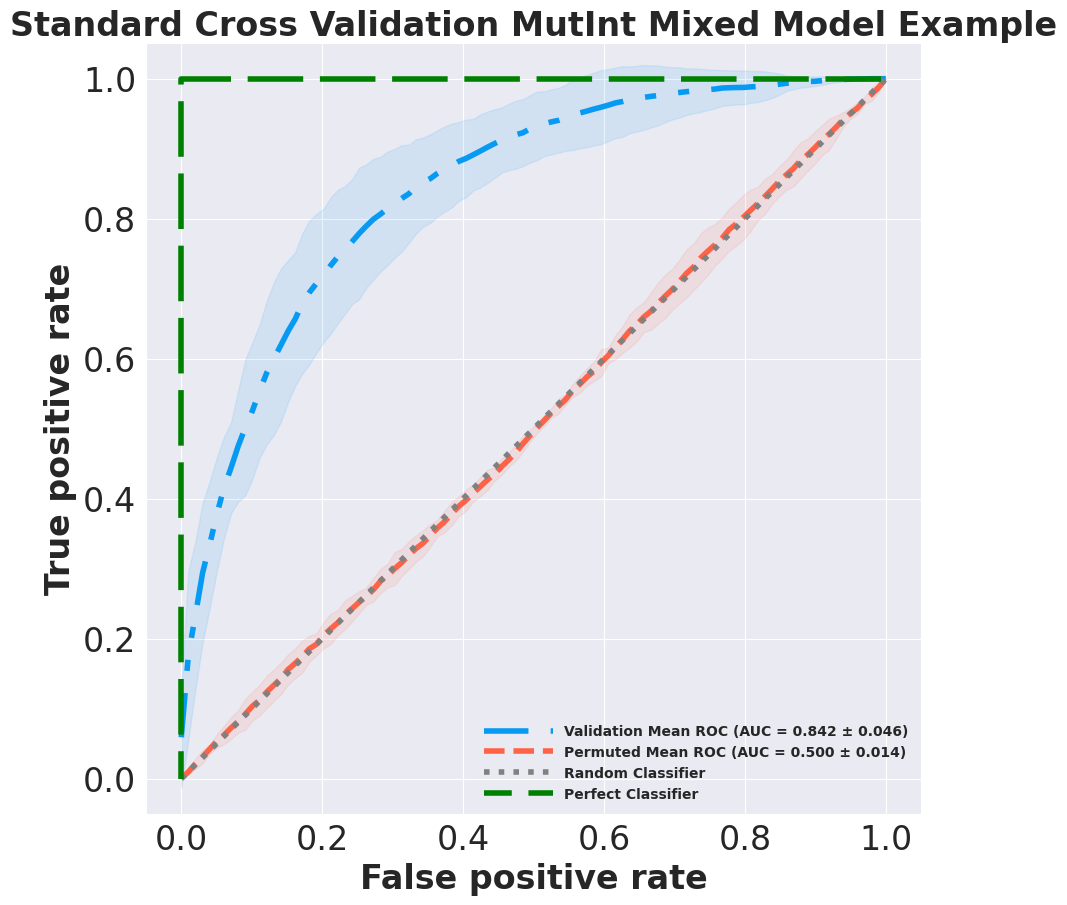

In [19]:
# Load pickle from example OR change to your SCV results
scv_df = pd.read_pickle('/home/lichangyong/documents/Ab_Ag/Our_abg/Ab_Ag_interaction_prediction/HIV/unseenab_results.pkl')

val_fpr = scv_df.FPRs.values
val_tpr = scv_df.TPRs.values
fpr_perm = scv_df.FPRperms.values
tpr_perm = scv_df.TPRperms.values
mean_auc = np.mean(scv_df.AUCs.values)
std_auc = np.std(scv_df.AUCs.values)
mean_auc_perm = np.mean(scv_df.PermYAUCs.values)
std_auc_perm = np.std(scv_df.PermYAUCs.values)

# Define a common set of FPR values
common_fpr = np.linspace(0, 1, 100)
common_fpr_perm = np.linspace(0, 1, 100)

interp_tpr = []
interp_tpr_perm = []

# Interpolate TPR values for each fold
for i in range(len(val_fpr)):
    interp_tpr.append(np.interp(common_fpr, val_fpr[i], val_tpr[i]))
    interp_tpr_perm.append(np.interp(common_fpr_perm, fpr_perm[i], tpr_perm[i]))

# Calculate the mean and standard deviation of the interpolated TPR values
mean_tpr = np.mean(interp_tpr, axis=0)
std_tpr = np.std(interp_tpr, axis=0)
mean_tpr_perm = np.mean(interp_tpr_perm, axis=0)
std_tpr_perm = np.std(interp_tpr_perm, axis=0)

# Create the plot
fig = plt.figure(figsize =(10, 10))
plt.plot(common_fpr, mean_tpr, color='#069AF3', label='Validation Mean ROC (AUC = %0.3f \u00B1 %0.3f)' % (mean_auc, 2*std_auc), linewidth = 4, dashes=[8, 4, 2, 4, 2, 4])
plt.fill_between(common_fpr, (mean_tpr - 2*std_tpr), (mean_tpr + 2*std_tpr), color='#069AF3', alpha=0.1)
plt.plot(common_fpr_perm, mean_tpr_perm, color='tomato', label='Permuted Mean ROC (AUC = %0.3f \u00B1 %0.3f)' % (mean_auc_perm, 2*std_auc_perm), linewidth = 4, linestyle='--')
plt.fill_between(common_fpr_perm, (mean_tpr_perm - 2*std_tpr_perm), (mean_tpr_perm + 2*std_tpr_perm), color='tomato', alpha=0.1)

# Customize the plot
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', linewidth=4, label='Random Classifier')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.plot([0, 0, 1], [0, 1, 1], linestyle=(5, (10, 3)), color='green', linewidth = 4, label='Perfect Classifier')
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.title('Standard Cross Validation MutInt Mixed Model Example', fontweight='bold', fontsize=24)
plt.xlabel('False positive rate', fontweight='bold', fontsize=24)
plt.ylabel('True positive rate', fontweight='bold', fontsize=24)
plt.legend(loc="lower right", prop={'size': 12, 'weight':'bold'}, handlelength=5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.legend(
    loc="lower right",
    prop={'size': 10, 'weight': 'bold'},
    handlelength=5,
    frameon=False  # 这一行就是去掉图例框的关键！
)
plt.show()